# <font color='red'>
---
## <center> <font color='red'> Masters in Mathematical Finance
#### <center> <font color='red'> 2024 / 26
# <center> <font color='red'> Masters' Final Work
---
# <center> <font color='red'><font> Student: Petr Terletskiy </font>
### <center> <font color='red'><font> Number: l63023 </font>
---
##### <center>  <font color='red'><font> Project on Bitcoin's Volatility and Option Pricing Model Selection</font>

---

| Column Name | What It Is | Why It's Useful for Your Project |
| :--- | :--- | :--- |
| **`Close`** | The final trading price of BTC for that day. | This is your primary price reference. All returns are calculated from it. |
| **`Volume`** | The total amount of BTC traded during the day. | High volume often confirms the strength of a price move and is correlated with volatility. |
| **`return_1d`** | The percentage change from yesterday's close to today's close: `(Close_t / Close_{t-1}) - 1`. | Easy to interpret (e.g., 0.02 means a 2% gain). It's the basis for calculating **realized volatility** (e.g., the standard deviation of these returns over the last 30 days). |
| **`log_return_1d`** | The logarithmic return: `log(Close_t / Close_{t-1})`. | **This is the standard in quantitative finance.** Log returns are time-additive, which is a very useful mathematical property. They also tend to be more normally distributed than simple returns, which is an assumption in many models. |
| **`intraday_range`** | The absolute difference between the day's high and low prices: `High - Low`. | A direct, raw measure of how much the price fluctuated *within* the day. A large range signifies high intraday volatility and uncertainty. |
| **`norm_intraday_range`** | The intraday range as a percentage of the day's opening price: `(High - Low) / Open`. | This is a **superior feature** to the raw range. By normalizing, you can compare the intraday volatility across different price levels. A $500 range meant something different when BTC was at $20,000 versus when it was at $60,000. This feature adjusts for that. |

# Dependencies

In [1]:
%pip install yfinance coinmetrics.api_client --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import requests

import yfinance as yf
from coinmetrics.api_client import CoinMetricsClient

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
#plt.style.use('seaborn-v0_8')
#sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


# Data Retrieval

`btc_spot`: data, preço, volume

`btc_options`: data, strike, maturity, preço_compra, preço_venda, volume, etc.

`btc_on_chain`: data, transacoes_unicas, taxa_hash, dificuldade, volume_usd, idade_media_moedas, percentagem_inativas, fluxo_exchange, open_interest, funding_rate

## OHLCV Data

In [21]:
# Download BTC ohlcv data from Yahoo Finance
ticker = 'BTC-USD'
ohlcv_btc_data = yf.download(ticker, start="2014-09-17", end="2026-02-07", interval="1d")
ohlcv_btc_data.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
print(f"\nData available: {ohlcv_btc_data.shape[0]} days and {ohlcv_btc_data.shape[1]} features.")
print(f"Period: {ohlcv_btc_data.index[0].date()} to {ohlcv_btc_data.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed


Data available: 4161 days and 5 features.
Period: 2014-09-17 to 2026-02-06


### Target Feature Definition

* If the `Close` price goes **down**, then the `Target` = **0**
* If the `Close` price goes **up**, then the `Target` = **1**

In [22]:
# Compute next day's close (shift backward) and give binary direction to the target variable
ohlcv_btc_data['Close_t+1'] = ohlcv_btc_data['Close'].shift(-1)
ohlcv_btc_data['Target'] = (ohlcv_btc_data['Close_t+1'] > ohlcv_btc_data['Close']).astype(int)

# Drop rows where Target is NaN (last row of dataset) and remove the helper column 'Close_t+1'
ohlcv_btc_data.dropna(subset=['Target'], inplace=True)
ohlcv_btc_data.drop(columns=['Close_t+1'], inplace=True)
ohlcv_btc_data.tail(7)

,Open,High,Low,Close,Volume,Target
Date,,,,,,
2026-01-31,78621.117188,84136.921875,75815.882812,84126.500000,70479259159,0
2026-02-01,76974.445312,79322.609375,75698.898438,78626.125000,53372509744,0
2026-02-02,78688.765625,79258.609375,74551.335938,76968.875000,75140589684,1
2026-02-03,75633.546875,79118.851562,72897.140625,78693.507812,68249110822,0
2026-02-04,73019.703125,76864.656250,71779.929688,75640.093750,67215363944,0
2026-02-05,62702.097656,73161.554688,62353.535156,73016.375000,125509410908,0
2026-02-06,70555.390625,71681.304688,60074.203125,62704.453125,114674259489,0


## On-chain Data


#### Coinmetrics

In [23]:
client = CoinMetricsClient()

# Display metrics available
list_asset_metrics = client.catalog_asset_metrics_v2(assets='btc')
btc_list = list_asset_metrics.to_dataframe()
btc_list

,asset,metric,frequency,min_time,max_time,min_height,max_height,min_hash,max_hash,community
0,btc,AdrActCnt,1d,2009-01-03 00:00:00+00:00,2026-02-11 00:00:00+00:00,None,None,None,None,True
1,btc,AdrBalCnt,1d,2009-01-03 00:00:00+00:00,2026-02-11 00:00:00+00:00,None,None,None,None,True
2,btc,AssetCompletionTime,1d,2009-01-03 00:00:00+00:00,2026-02-11 00:00:00+00:00,None,None,None,None,True
3,btc,AssetEODCompletionTime,1d,2009-01-03 00:00:00+00:00,2026-02-11 00:00:00+00:00,None,None,None,None,True
4,btc,BlkCnt,1d,2009-01-03 00:00:00+00:00,2026-02-11 00:00:00+00:00,None,None,None,None,True
5,btc,CapMVRVCur,1d,2010-07-18 00:00:00+00:00,2026-02-11 00:00:00+00:00,None,None,None,None,True
6,btc,CapMrktCurUSD,1d,2010-07-18 00:00:00+00:00,2026-02-11 00:00:00+00:00,None,None,None,None,True
7,btc,CapMrktEstUSD,1d,2019-06-22 00:00:00+00:00,2026-02-11 00:00:00+00:00,None,None,None,None,True
8,btc,FeeTotNtv,1d,2009-01-03 00:00:00+00:00,2026-02-11 00:00:00+00:00,None,None,None,None,True
9,btc,FlowInExNtv,1d,2009-01-03 00:00:00+00:00,2026-02-11 00:00:00+00:00,None,None,None,None,True


In [24]:
# Filter for metrics with frequency == '1d'
daily_metrics = btc_list[btc_list['frequency'] == '1d']
daily_metrics_names = daily_metrics['metric'].tolist()

# Print the list
print(f"Total daily metrics: {len(daily_metrics_names)}")
print(daily_metrics_names)

Total daily metrics: 31
['AdrActCnt', 'AdrBalCnt', 'AssetCompletionTime', 'AssetEODCompletionTime', 'BlkCnt', 'CapMVRVCur', 'CapMrktCurUSD', 'CapMrktEstUSD', 'FeeTotNtv', 'FlowInExNtv', 'FlowInExUSD', 'FlowOutExNtv', 'FlowOutExUSD', 'HashRate', 'IssTotNtv', 'IssTotUSD', 'PriceBTC', 'PriceUSD', 'ROI1yr', 'ROI30d', 'ReferenceRate', 'ReferenceRateETH', 'ReferenceRateEUR', 'ReferenceRateUSD', 'SplyCur', 'SplyExNtv', 'SplyExUSD', 'SplyExpFut10yr', 'TxCnt', 'TxTfrCnt', 'volume_reported_spot_usd_1d']


In [27]:
btc_metrics = client.get_asset_metrics(assets = 'btc', metrics = daily_metrics_names,
                                   start_time = '2014-09-17', end_time = '2026-02-07', frequency = '1d')

# Convert to DataFrame directly
btc_coinmetrics = btc_metrics.to_dataframe()

# Convert timestamp to datetime and set 'Date' as index
btc_coinmetrics['time'] = pd.to_datetime(btc_coinmetrics['time'])
btc_coinmetrics['time'] = btc_coinmetrics['time'].dt.tz_localize(None).dt.normalize()
btc_coinmetrics.set_index('time', inplace=True)
btc_coinmetrics.index.name = 'Date'
btc_coinmetrics

,asset,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,...,SplyExNtv,SplyExNtv-status,SplyExNtv-status-time,SplyExUSD,SplyExUSD-status,SplyExUSD-status-time,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
Date,,,,,,,,,,,,,,,,,,,,,
2014-09-17,btc,191063,3404363,1614336399,1614336399,186,1.285606,6060691069.13061,<NA>,12.040404,...,417305.412444,reviewed,2020-02-28T09:17:32.260416000Z,190433106.549981,reviewed,2020-02-28T09:17:32.260416000Z,19708906.25,78526,193554,11961580.812249
2014-09-18,btc,190890,3412475,1614336400,1614336400,179,1.205033,5671343316.691176,<NA>,12.215005,...,425198.293926,reviewed,2020-02-28T09:17:32.260416000Z,181508693.188384,reviewed,2020-02-28T09:17:32.260416000Z,19709465.625,76357,192000,29729670.258177
2014-09-19,btc,172255,3418017,1614336400,1614336400,171,1.115123,5234786700.077503,<NA>,10.819493,...,427132.470154,reviewed,2020-02-28T09:17:32.260416000Z,168244870.516347,reviewed,2020-02-28T09:17:32.260416000Z,19710000.0,70093,170839,28559984.972858
2014-09-20,btc,169941,3420176,1614336401,1614336401,176,1.166208,5464482172.793501,<NA>,10.303744,...,428736.201266,reviewed,2020-02-28T09:17:32.260416000Z,176228303.867605,reviewed,2020-02-28T09:17:32.260416000Z,19710550.0,64168,169223,23384116.542328
2014-09-21,btc,200712,3435000,1614336402,1614336402,164,1.136713,5324715500.714623,<NA>,9.086879,...,427755.457953,reviewed,2020-02-28T09:17:32.260416000Z,171275223.389278,reviewed,2020-02-28T09:17:32.260416000Z,19711062.5,57668,238140,15423671.767001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-03,btc,741467,56068313,1770175208,1770175208,132,1.359791,1512475464307.300049,1512382643973.246338,3.222623,...,2682567.194828,flash,2026-02-04T02:30:36.571135000Z,203029470494.320312,flash,2026-02-04T03:06:01.149872000Z,20828528.125,435204,973766,21213971974.451599
2026-02-04,btc,704812,56054703,1770265085,1770265085,142,1.315931,1460758146742.279297,1460636066292.049316,3.098569,...,2685518.322995,flash,2026-02-05T02:35:46.512651000Z,196298476001.125916,flash,2026-02-05T03:13:43.922892000Z,20828639.0625,412289,885625,21358802735.676998
2026-02-05,btc,865167,56091748,1770347200,1770347200,127,1.149795,1268923762593.203125,1268910363178.269775,6.147239,...,2693585.647283,flash,2026-02-06T02:05:42.068376000Z,171028381475.890289,flash,2026-02-06T02:43:48.093272000Z,20828738.28125,384528,890334,43176820261.097198


#### Blockchain.com

In [7]:
'''
import requests
import pandas as pd
from datetime import datetime, timedelta
import time

# Métricas disponíveis na Blockchain.com (gratuitas)
metrics = {
    'n-transactions': 'transactions',
    'n-unique-addresses': 'unique_addresses',
    'hash-rate': 'hash_rate',
    'difficulty': 'difficulty', 
    'miners-revenue': 'miners_revenue',
    'transaction-fees': 'transaction_fees',
    'market-price': 'market_price',
    'total-bitcoins': 'total_bitcoins',
    'mempool-size': 'mempool_size'
}

base_url = "https://api.blockchain.info/charts/"

# Calcular timespan em dias
start = datetime(2011, 1, 1)
end = datetime(2025, 11, 30)
timespan = (end - start).days

print("A obter dados da Blockchain.com...")
all_data = {}

for metric_key, metric_name in metrics.items():
    try:
        url = f"{base_url}{metric_key}"
        params = {
            'timespan': f'{timespan}days',
            'format': 'json',
            'sampled': 'false'
        }

        response = requests.get(url, params=params)

        if response.status_code == 200:
            data = response.json()
            values = data.get('values', [])

            # Converter timestamps para datas
            df_temp = pd.DataFrame(values)
            df_temp['date'] = pd.to_datetime(df_temp['x'], unit='s')
            df_temp = df_temp.rename(columns={'y': metric_name})
            df_temp = df_temp[['date', metric_name]]

            all_data[metric_name] = df_temp
            print(f"✓ {metric_name}: {len(df_temp)} pontos")
        else:
            print(f"✗ {metric_name}: erro {response.status_code}")

        time.sleep(0.5)  # Pausa para não sobrecarregar API

    except Exception as e:
        print(f"✗ {metric_name}: {e}")

# Combinar todos os dataframes
if all_data:
    df_final = None
    for metric_name, df_temp in all_data.items():
        if df_final is None:
            df_final = df_temp
        else:
            df_final = pd.merge(df_final, df_temp, on='date', how='outer')

    df_final = df_final.sort_values('date')

    # Apenas exibir informações, sem salvar CSV
    print(f"\n✓ Dados processados com sucesso!")
    print(f"Período: {df_final['date'].min()} até {df_final['date'].max()}")
    print(f"Dimensões: {len(df_final)} linhas × {len(df_final.columns)} colunas")
    print(f"Colunas disponíveis: {list(df_final.columns)}")
    
    # Mostrar estatísticas básicas
    print(f"\nEstatísticas básicas:")
    print(df_final.describe())
    
    # Mostrar primeiras e últimas linhas
    print(f"\nPrimeiras 5 linhas:")
    print(df_final.head())
    print(f"\nÚltimas 5 linhas:")
    print(df_final.tail())
    
    # Agora df_final está disponível para uso no seu projeto
    # Pode usá-lo diretamente para análise ou modelação
else:
    print("Nenhum dado foi obtido.")
    df_final = pd.DataFrame()  # Dataframe vazio para evitar erros

# O dataframe 'df_final' agora está disponível para uso no seu projeto
# Pode continuar a trabalhar com ele, por exemplo:
# - Criar features adicionais
# - Combinar com dados de outras fontes
# - Treinar modelos de machine learning
'''

'\nimport requests\nimport pandas as pd\nfrom datetime import datetime, timedelta\nimport time\n\n# Métricas disponíveis na Blockchain.com (gratuitas)\nmetrics = {\n    \'n-transactions\': \'transactions\',\n    \'n-unique-addresses\': \'unique_addresses\',\n    \'hash-rate\': \'hash_rate\',\n    \'difficulty\': \'difficulty\', \n    \'miners-revenue\': \'miners_revenue\',\n    \'transaction-fees\': \'transaction_fees\',\n    \'market-price\': \'market_price\',\n    \'total-bitcoins\': \'total_bitcoins\',\n    \'mempool-size\': \'mempool_size\'\n}\n\nbase_url = "https://api.blockchain.info/charts/"\n\n# Calcular timespan em dias\nstart = datetime(2011, 1, 1)\nend = datetime(2025, 11, 30)\ntimespan = (end - start).days\n\nprint("A obter dados da Blockchain.com...")\nall_data = {}\n\nfor metric_key, metric_name in metrics.items():\n    try:\n        url = f"{base_url}{metric_key}"\n        params = {\n            \'timespan\': f\'{timespan}days\',\n            \'format\': \'json\',\n    

## Merging the Datasets

In [52]:
# Merge with left join (keep all Yahoo dates)
btc_data = pd.merge(ohlcv_btc_data, btc_coinmetrics, left_index=True, right_index=True, how='left')

print(f"Left merged dataset shape: {btc_data.shape}")
print(f"Yahoo dates: {ohlcv_btc_data.shape[0]}, CoinMetrics dates: {btc_coinmetrics.shape[0]}")
print(f"Merged dates: {btc_data.shape[0]}")
print(f"Missing CoinMetrics data for {btc_data[btc_data['PriceUSD'].isna()].shape[0]} dates")

Left merged dataset shape: (4161, 50)
Yahoo dates: 4161, CoinMetrics dates: 4162
Merged dates: 4161
Missing CoinMetrics data for 0 dates


# Train-Test Split

In [54]:
print(f'Dates range from {btc_data.index[0]} to {btc_data.index[-1]}.')

Dates range from 2014-09-17 00:00:00 to 2026-02-06 00:00:00.


Train: 2014-09-17 00:00:00 to 2021-12-31 00:00:00;  shape=(2663, 50)
  Val: 2022-01-01 00:00:00 to 2023-12-31 00:00:00;  shape=(730, 50)
 Test: 2024-01-01 00:00:00 to 2026-02-06 00:00:00;  shape=(768, 50)


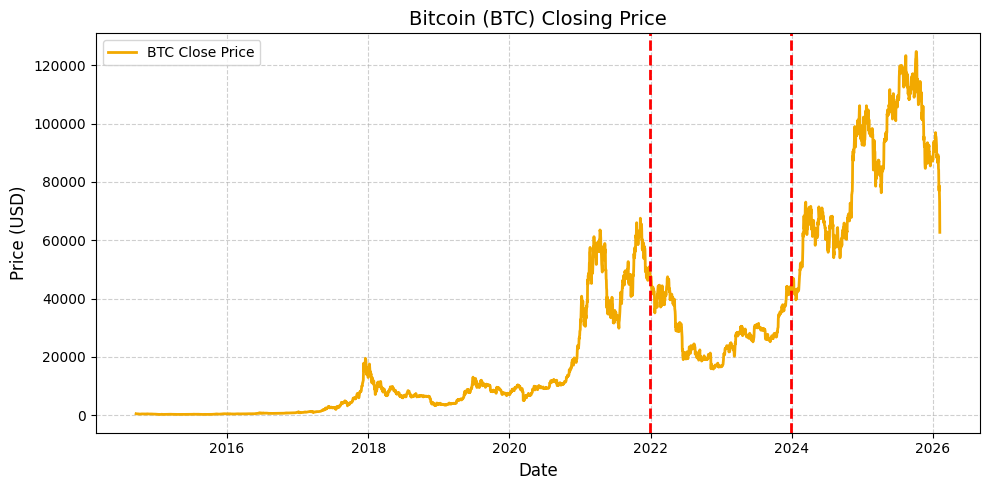

In [55]:
# Define split dates
train_end = '2021-12-31'
val_end   = '2023-12-31'

btc_train = btc_data.loc[:train_end].copy()
btc_val   = btc_data.loc[train_end:val_end].iloc[1:].copy()   
btc_test  = btc_data.loc[val_end:].iloc[1:].copy()

print(f"Train: {btc_train.index[0]} to {btc_train.index[-1]};  shape={btc_train.shape}")
print(f"  Val: {btc_val.index[0]} to {btc_val.index[-1]};  shape={btc_val.shape}")
print(f" Test: {btc_test.index[0]} to {btc_test.index[-1]};  shape={btc_test.shape}")

plt.figure(figsize=(10, 5))
plt.plot(btc_data.index, btc_data['Close'], color='#f2a900', linewidth=2, label='BTC Close Price')

# Adding labels and title
plt.axvline(x=pd.to_datetime(train_end), color='red', linestyle='--', linewidth=2)
plt.axvline(x=pd.to_datetime(val_end), color='red', linestyle='--', linewidth=2)
plt.title('Bitcoin (BTC) Closing Price', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

# Aesthetic improvements
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Exploratory Data Analysis

### Dataset Overview

In [93]:
btc_train.describe()

,Open,High,Low,Close,Volume,Target,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,...,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
count,2663.000000,2663.000000,2663.000000,2663.000000,2.663000e+03,2663.000000,2663.0,2663.0,2663.0,2663.0,...,0.0,0.0,0.0,2663.0,2663.0,2663.0,2663.0,2663.0,2663.0,2663.0
mean,10760.231327,11039.547764,10422.788567,10744.807578,1.447025e+10,0.540368,672320.595193,20701463.900488,1615888258.033046,1615888258.033046,...,<NA>,<NA>,<NA>,16788967.300967,1066743.422177,15557097090.412983,20256470.992537,244879.280511,612413.223057,3952871904.796362
std,15716.157142,16140.428385,15212.610693,15706.804781,2.007104e+10,0.498461,259783.835717,11110327.128335,5022885.88049,5022885.88049,...,<NA>,<NA>,<NA>,1596053.423507,460073.544258,24352523445.034458,276022.238747,80577.794282,206179.541729,6545664779.275536
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06,0.000000,145765.0,3404363.0,1614336399.0,1614336399.0,...,<NA>,<NA>,<NA>,13281089.785897,235564.023846,58379716.372379,19708906.25,57668.0,152648.0,3287344.948737
25%,596.207001,601.594513,587.149475,594.467499,7.753150e+07,0.000000,496487.5,9398868.0,1614336844.0,1614336844.0,...,<NA>,<NA>,<NA>,15758517.354738,638450.479553,387071400.411556,20019670.3125,195896.5,486436.5,50577254.193935
50%,6173.229980,6308.509766,5920.085938,6164.279785,4.935290e+09,1.000000,675915.0,22398175.0,1614337278.0,1614337278.0,...,<NA>,<NA>,<NA>,17026611.085797,1235569.312038,7820872377.193972,20336696.875,254125.0,621080.0,1429027349.42378
75%,10217.739746,10406.964355,9922.276367,10202.907227,2.432886e+10,1.000000,850061.0,29433575.5,1614337712.5,1614337712.5,...,<NA>,<NA>,<NA>,18255736.07115,1508827.4198,14874600708.60957,20493864.84375,307300.0,748070.5,4071178127.26568
max,67566.828125,68789.625000,66382.062500,67549.734375,3.509679e+11,1.000000,1366494.0,39884981.0,1641012225.0,1641012225.0,...,<NA>,<NA>,<NA>,18916068.791431,1685855.350889,108449257082.642761,20644068.75,498142.0,2041653.0,74786385767.957993


In [96]:
btc_train.describe(exclude=['number'])

,asset,FlowInExNtv-status,FlowInExNtv-status-time,FlowInExUSD-status,FlowInExUSD-status-time,FlowOutExNtv-status,FlowOutExNtv-status-time,FlowOutExUSD-status,FlowOutExUSD-status-time,SplyExNtv-status,SplyExNtv-status-time,SplyExUSD-status,SplyExUSD-status-time
count,2663,2663,2663,2663,2663,2663,2663,2663,2663,2663,2663,2663,2663
unique,1,1,3,1,3,1,3,1,3,1,3,1,3
top,btc,reviewed,2020-02-28T09:17:32.260416000Z,reviewed,2020-02-28T09:17:32.260416000Z,reviewed,2020-02-28T09:17:32.260416000Z,reviewed,2020-02-28T09:17:32.260416000Z,reviewed,2020-02-28T09:17:32.260416000Z,reviewed,2020-02-28T09:17:32.260416000Z
freq,2663,2663,1882,2663,1882,2663,1882,2663,1882,2663,1882,2663,1882


In [63]:
target_feature = 'Target'


#### Target Feature



Distribution of the Target feature:


Target
1    1439
0    1224
Name: count, dtype: int64

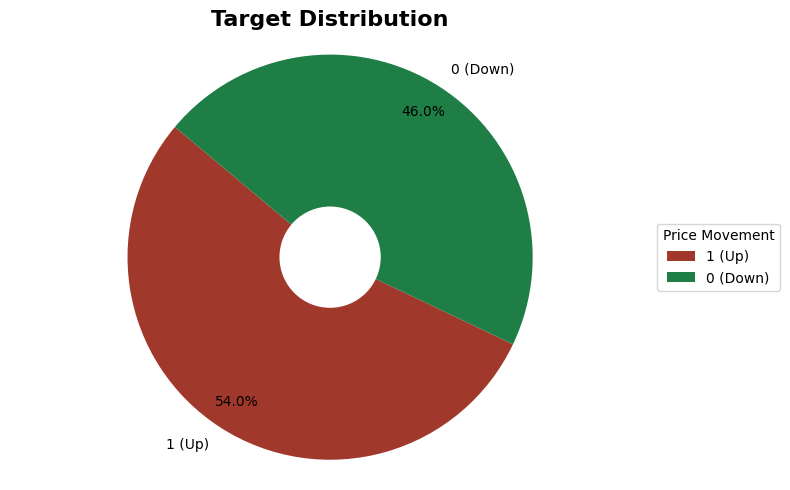

In [92]:
print('\n')
print(f'Distribution of the {target_feature} feature:')

# value counts
value_counts = btc_train[target_feature].value_counts(dropna=False)
display(value_counts)
print('\n')

# donut chart
label_map = {0: '0 (Down)', 1: '1 (Up)'}
labels = [label_map.get(x, str(x)) for x in value_counts.index]

plt.figure(figsize=(8, 5))
colors = ["#a0382c", "#1e7e46"] # Red for Down, Green for Up

patches, texts, autotexts = plt.pie(value_counts, labels=labels, 
                                    autopct='%1.1f%%', startangle=140, 
                                    colors=colors, pctdistance=0.85)

centre_circle = plt.Circle((0,0), 0.25, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.legend(patches, labels, title="Price Movement", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title(f'{target_feature} Distribution', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [67]:
# Number of unique values per feature
for column in btc_train.columns:
    unique_count = btc_train[column].nunique()
    print(f"Column '{column}' has {unique_count} unique values.")

Column 'Open' has 2660 unique values.
Column 'High' has 2660 unique values.
Column 'Low' has 2662 unique values.
Column 'Close' has 2659 unique values.
Column 'Volume' has 2663 unique values.
Column 'Target' has 2 unique values.
Column 'asset' has 1 unique values.
Column 'AdrActCnt' has 2661 unique values.
Column 'AdrBalCnt' has 2663 unique values.
Column 'AssetCompletionTime' has 1853 unique values.
Column 'AssetEODCompletionTime' has 1853 unique values.
Column 'BlkCnt' has 110 unique values.
Column 'CapMVRVCur' has 2663 unique values.
Column 'CapMrktCurUSD' has 2663 unique values.
Column 'CapMrktEstUSD' has 924 unique values.
Column 'FeeTotNtv' has 2663 unique values.
Column 'FlowInExNtv' has 2663 unique values.
Column 'FlowInExNtv-status' has 1 unique values.
Column 'FlowInExNtv-status-time' has 3 unique values.
Column 'FlowInExUSD' has 2663 unique values.
Column 'FlowInExUSD-status' has 1 unique values.
Column 'FlowInExUSD-status-time' has 3 unique values.
Column 'FlowOutExNtv' has

# Data Preprocessing

In [61]:
btc_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2663 entries, 2014-09-17 to 2021-12-31
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Open                         2663 non-null   float64
 1   High                         2663 non-null   float64
 2   Low                          2663 non-null   float64
 3   Close                        2663 non-null   float64
 4   Volume                       2663 non-null   int64  
 5   Target                       2663 non-null   int64  
 6   asset                        2663 non-null   string 
 7   AdrActCnt                    2663 non-null   Int64  
 8   AdrBalCnt                    2663 non-null   Int64  
 9   AssetCompletionTime          2663 non-null   Int64  
 10  AssetEODCompletionTime       2663 non-null   Int64  
 11  BlkCnt                       2663 non-null   Int64  
 12  CapMVRVCur                   2663 non-null   Float64
 13  

In [60]:
# returns True if no duplicate dates
btc_train.index.is_unique   

True